In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/genz_mental_wellness_synthetic_dataset.csv")

In [3]:
burnout_pipeline = joblib.load(
    "../models/burnout_model.pkl"
)

wellbeing_pipeline = joblib.load(
    "../models/wellbeing_model.pkl"
)

In [4]:
X_burnout = df.drop(
    ["Burnout_Risk", "Wellbeing_Index"],
    axis=1
)

In [5]:
X_wellbeing = df.drop(
    ["Wellbeing_Index", "Burnout_Risk"],
    axis=1
)

In [6]:
preprocessor = wellbeing_pipeline.named_steps[
    "preprocessor"
]

model = wellbeing_pipeline.named_steps[
    "model"
]

In [7]:
X_transformed = preprocessor.transform(
    X_wellbeing
)

In [8]:
feature_names = preprocessor.get_feature_names_out()

In [9]:
len(feature_names)

33

In [10]:
X_transformed.shape

(10000, 33)

In [11]:
explainer = shap.TreeExplainer(model)

In [12]:
sample_size = 500

X_sample = X_transformed[:sample_size]

shap_values = explainer.shap_values(
    X_sample
)

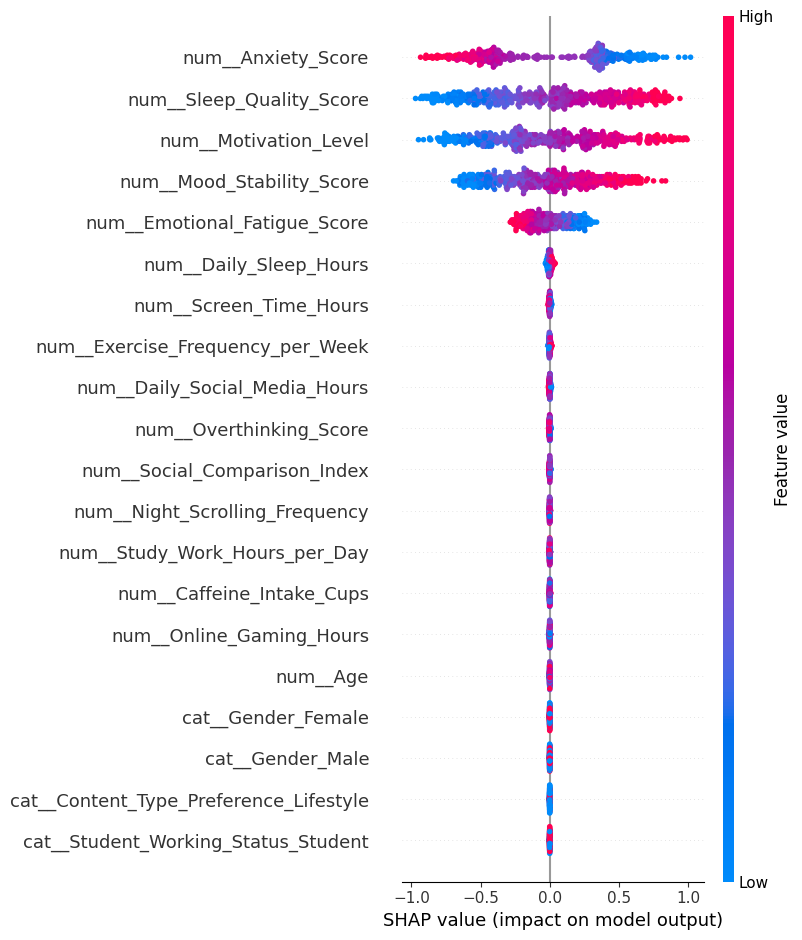

In [13]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names
)

In [14]:
user_idx = 0

In [15]:
shap.initjs()

In [16]:
shap.force_plot(
    explainer.expected_value,
    shap_values[user_idx],
    X_sample[user_idx],
    feature_names=feature_names
)

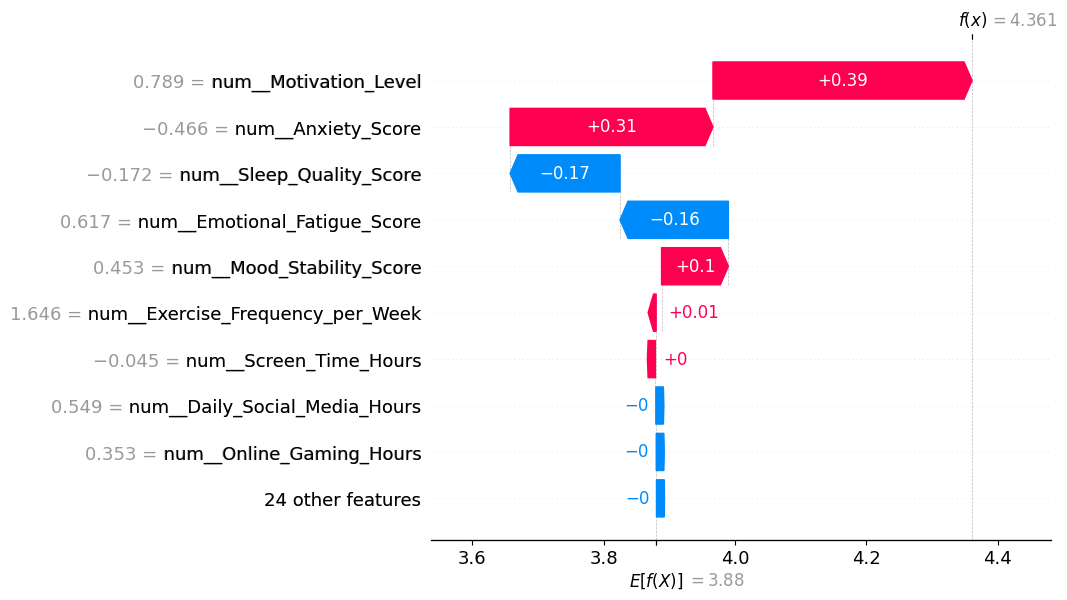

In [17]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[user_idx],
        base_values=explainer.expected_value,
        data=X_sample[user_idx],
        feature_names=feature_names
    )
)

In [18]:
preprocessor = burnout_pipeline.named_steps[
    "preprocessor"
]
model = burnout_pipeline.named_steps[
    "model"
]

In [19]:
X_transformed = preprocessor.transform(
    X_burnout
)

In [20]:
explainer = shap.TreeExplainer(model)

In [21]:
shap_values = explainer.shap_values(
    X_transformed[:500]
)

In [22]:
type(shap_values)

numpy.ndarray

In [23]:
preprocessor = burnout_pipeline.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))
print(feature_names[:20])

33
['num__Age' 'num__Daily_Social_Media_Hours' 'num__Screen_Time_Hours'
 'num__Night_Scrolling_Frequency' 'num__Online_Gaming_Hours'
 'num__Exercise_Frequency_per_Week' 'num__Daily_Sleep_Hours'
 'num__Caffeine_Intake_Cups' 'num__Study_Work_Hours_per_Day'
 'num__Overthinking_Score' 'num__Anxiety_Score'
 'num__Mood_Stability_Score' 'num__Social_Comparison_Index'
 'num__Sleep_Quality_Score' 'num__Motivation_Level'
 'num__Emotional_Fatigue_Score' 'cat__Gender_Female' 'cat__Gender_Male'
 'cat__Gender_Non-binary' 'cat__Country_Australia']
